# Bond Mathematics: Duration, Convexity & Immunization

A from-scratch exploration of interest rate risk measures — Macaulay and modified duration, convexity, key rate duration, and portfolio immunization — built entirely with NumPy.

### Why this notebook matters

Duration and convexity are the workhorses of fixed-income risk management. Every bond portfolio manager, every asset-liability matcher, every fixed-income trader uses these concepts daily. They form the bridge between *yield* (what you earn) and *price risk* (what you lose if rates move).

> **Key Concept:** Duration answers: *"If yields rise 1%, what happens to my bond price?"* Convexity refines that answer by accounting for the curvature in the price-yield relationship. Together, they convert the abstract concept of interest rate risk into actionable numbers — measured in dollars or percentage terms.

## 1. Motivation

Bond prices move inversely with interest rates, but **how much** do they move? This is the central question of **interest rate risk management**.

### Why This Matters in the Real World

In March 2023, Silicon Valley Bank collapsed largely because of duration risk. The bank held a massive portfolio of long-term government bonds. When interest rates rose sharply, those bonds lost billions in value, wiping out the bank's equity. The management had failed to properly measure and hedge their interest rate exposure — a failure of the exact tools we build in this notebook.

Duration and convexity are not abstract academic concepts. They are the daily language of:
- **Bond portfolio managers** who need to know how much their portfolio will gain or lose if rates move
- **Risk managers** who set limits on interest rate exposure
- **Pension fund managers** who must ensure their assets can meet future obligations
- **Central bank analysts** who model the impact of monetary policy on financial markets

### What We Will Cover

| Concept | What It Measures | Why It Matters |
|---------|-----------------|----------------|
| Macaulay Duration | Weighted-average time to cash flows | Tells you the bond's "effective maturity" |
| Modified Duration | % price change per 1% yield change | The primary risk measure for bonds |
| Effective Duration | Rate sensitivity for bonds with embedded options | Works for callable/putable bonds |
| Convexity | Curvature of the price-yield relationship | Corrects duration's linear approximation |
| Key Rate Duration | Sensitivity to individual yield curve points | Measures non-parallel shift risk |
| Immunization | Protecting a portfolio against rate changes | Matching assets to liabilities |

> **CFA Exam Tip:** Duration and convexity are among the most heavily tested topics at CFA Level I and II. You must be able to compute them, interpret them, and apply them to portfolio management scenarios. Understanding the *intuition* behind these measures is just as important as knowing the formulas.

### The economic stakes

Interest rate risk is the single largest exposure for most bond investors. Consider:
* The 2022 bond market suffered its worst calendar-year loss in over 50 years as the Fed raised rates aggressively
* The 30-year Treasury bond fell over 30% from its 2020 peak to 2023 trough
* Pension funds and insurance companies — the largest bond holders — must precisely match assets to liabilities to avoid catastrophic losses

Without duration, convexity, and immunization, these institutions would have no systematic way to manage trillions of dollars in interest rate exposure.

> **Key Concept:** Bond mathematics is not just academic. It is the operational toolkit that enables modern fixed-income markets to function. Every Treasury auction, every pension liability assessment, every insurance reserve calculation depends on the concepts in this notebook.

## 2. Setup## 2. Setup

This notebook uses synthetic but realistic bond examples — coupon rates from 0% (zero-coupon) to 10%, maturities from 2 to 30 years, and yields ranging from 1% to 10%. Every formula is implemented from scratch using NumPy, with results verified against analytical bounds and standard published values.

The progression follows the natural learning order: bond pricing → duration → convexity → duration-convexity approximation → key rate duration → immunization. Each concept builds on the previous, so working through the notebook sequentially is recommended.

In [1]:
%matplotlib inline
import numpy as np
from scipy import linalg, optimize
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
rng = np.random.default_rng(SEED)

ATOL = 1e-10
RTOL = 1e-6

PRIMARY   = 'steelblue'
SECONDARY = 'coral'
TERTIARY  = 'seagreen'
ACCENT    = 'gold'
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12, 'axes.grid': True, 'grid.alpha': 0.3})

## 3. Bond Pricing Review

### How Bonds Work

A bond is essentially an IOU. The issuer (government or corporation) borrows money from investors and promises to:
1. Pay periodic **coupon** payments (like rent on the borrowed money)
2. Return the **face value** (principal) at maturity

For example, a 10-year, 5% coupon bond with $1,000 face value pays:
- $25 every 6 months for 10 years (semi-annual coupons = 5% / 2 x $1,000)
- $1,000 at the end of year 10

### The Price-Yield Relationship

A bond's price is the present value of all its future cash flows, discounted at the yield to maturity (YTM):

$$P = \sum_{i=1}^{n} \frac{C/m}{(1 + y/m)^i} + \frac{F}{(1 + y/m)^n}$$

where:
- $P$ = bond price
- $C$ = annual coupon payment ($= F \times c$, where $c$ is the coupon rate)
- $F$ = face value
- $y$ = yield to maturity (annual)
- $m$ = coupon frequency per year (usually 2 for semi-annual)
- $n$ = total number of coupon periods

### The Three Price Zones

| Condition | Bond Trades At | Intuition |
|-----------|---------------|-----------|
| Coupon rate > YTM | **Premium** (Price > Face) | Bond pays more than the market demands, so investors pay extra |
| Coupon rate = YTM | **Par** (Price = Face) | Bond pays exactly what the market demands |
| Coupon rate < YTM | **Discount** (Price < Face) | Bond pays less than the market demands, so investors pay less |

### Worked Example

Price a 10-year, 5% coupon bond (semi-annual, $100 face) at a 6% YTM:

- Coupon per period: $C/m = 100 \times 0.05/2 = \$2.50$
- Yield per period: $y/m = 0.06/2 = 0.03$
- Number of periods: $n = 10 \times 2 = 20$

$$P = 2.50 \times \frac{1 - (1.03)^{-20}}{0.03} + \frac{100}{(1.03)^{20}} = 2.50 \times 14.8775 + 55.3676 = \$92.56$$

Since the coupon rate (5%) < YTM (6%), the bond trades at a discount ($92.56 < $100).

> **Key Concept:** The price-yield relationship is **inverse** and **convex**. When yields go up, prices go down — but the relationship is not a straight line. It curves, and that curvature (convexity) is always in the bondholder's favor.

> **CFA Exam Tip:** A bond's price converges to par (face value) as it approaches maturity, regardless of whether it currently trades at a premium or discount. This is called "pull to par."

### Yield to maturity vs current yield

Two common bond yield metrics that look similar but measure different things:

**Current yield** = Annual coupon / Current price
* Simple to compute
* Ignores capital gain/loss from price-to-par convergence
* Useful for comparing income across bonds

**Yield to maturity (YTM)** = The internal rate of return assuming you hold to maturity
* Accounts for capital gain/loss as bond converges to par
* Standard quoted yield in bond markets
* Solved iteratively from the bond price equation

For a par bond, current yield = YTM = coupon rate. They diverge for premium and discount bonds:
* **Premium bond:** Current yield > YTM (you're earning a higher coupon now but will lose principal)
* **Discount bond:** Current yield < YTM (lower coupon now but will gain principal)

> **CFA Exam Tip:** When the exam asks about "yield," default to YTM unless explicitly told otherwise. Current yield is more of a quick-comparison metric than a true return measure.

The code below implements bond pricing and verifies the premium/discount/par relationships across different YTM levels.The code below implements bond pricing and verifies the premium/discount/par relationships.

### The fundamental bond pricing formula

The price of a coupon bond is the present value of its cash flows:

$$P = \sum_{t=1}^{N} \frac{C}{(1 + y/m)^t} + \frac{F}{(1 + y/m)^N}$$

where:
* $C$ = periodic coupon payment
* $F$ = face value
* $y$ = annual yield (YTM)
* $m$ = compounding frequency (2 for semi-annual)
* $N$ = total number of coupon periods

This is just the time-value-of-money formula applied to a sequence of known cash flows. The complexity comes from the fact that we usually solve for $y$ given $P$ (the YTM problem) — an iterative root-finding exercise.

> **CFA Exam Tip:** The CFA exam frequently tests the relationship: *if coupon = YTM, bond trades at par; if coupon > YTM, bond trades at premium; if coupon < YTM, bond trades at discount*. Memorise this triplet — it's the foundation of bond price intuition.

In [2]:
def bond_price(face, coupon_rate, ytm, n_periods, freq=2):
    """Price a fixed-coupon bond.
    
    Parameters
    ----------
    face : float        — face (par) value
    coupon_rate : float — annual coupon rate
    ytm : float         — annual yield to maturity
    n_periods : int     — total number of coupon periods remaining
    freq : int          — coupon payments per year
    
    Returns
    -------
    float — dirty price
    """
    c = face * coupon_rate / freq  # coupon per period
    y = ytm / freq                  # yield per period
    
    if abs(y) < 1e-15:
        return c * n_periods + face
    
    # Cash flow approach (explicit, no closed-form shortcut)
    periods = np.arange(1, n_periods + 1)
    discount_factors = (1.0 + y) ** (-periods)
    
    coupon_pv = c * np.sum(discount_factors)
    face_pv = face * discount_factors[-1]
    
    return coupon_pv + face_pv


def bond_cash_flows(face, coupon_rate, n_periods, freq=2):
    """Generate cash flow vector and time vector for a bond."""
    c = face * coupon_rate / freq
    times = np.arange(1, n_periods + 1) / freq  # in years
    cfs = np.full(n_periods, c)
    cfs[-1] += face  # add principal to last cash flow
    return times, cfs


def accrued_interest(face, coupon_rate, freq, days_since_coupon, days_in_period):
    """Compute accrued interest."""
    c = face * coupon_rate / freq
    return c * days_since_coupon / days_in_period


# --- Example: 5% coupon, 10-year bond ---
face = 100.0
coupon_rate = 0.05
freq = 2
n_periods = 20  # 10 years x 2

ytm_values = np.array([0.03, 0.04, 0.05, 0.06, 0.07])

print(f"Bond: {coupon_rate:.0%} coupon, {n_periods//freq}-year, semi-annual, face=${face:.0f}")
print("-" * 50)
for y in ytm_values:
    p = bond_price(face, coupon_rate, y, n_periods, freq)
    label = 'PREMIUM' if p > face else ('DISCOUNT' if p < face else 'PAR')
    print(f"  YTM = {y:.1%}  =>  Price = ${p:>8.4f}  ({label})")

Bond: 5% coupon, 10-year, semi-annual, face=$100
--------------------------------------------------
  YTM = 3.0%  =>  Price = $117.1686  (PREMIUM)
  YTM = 4.0%  =>  Price = $108.1757  (PREMIUM)
  YTM = 5.0%  =>  Price = $100.0000  (PREMIUM)
  YTM = 6.0%  =>  Price = $ 92.5613  (DISCOUNT)
  YTM = 7.0%  =>  Price = $ 85.7876  (DISCOUNT)


**Interpreting the output:** At a 3% YTM (below the 5% coupon), the bond trades at a premium ($117+). At exactly 5% YTM (equal to the coupon), the bond trades at par ($100). At 7% YTM (above the coupon), the bond trades at a deep discount ($85+). This confirms the inverse relationship between yields and prices.

### What Does This Mean for a Portfolio Manager?

If you hold a bond portfolio and the Federal Reserve raises interest rates by 1%, every bond in your portfolio loses value. The critical question is: **how much?** That is exactly what duration answers.**Interpreting the output:** At a 3% YTM (below the 5% coupon), the bond trades at a premium ($1,089). At 5%, it's at par. At 7%, it trades at a discount ($859).

### The premium-to-par convergence

A bond trading at a premium will *converge to par* as it approaches maturity, even if interest rates don't change. This is because:
1. The premium reflects the present value of "extra" coupon income (above the market rate)
2. As maturity approaches, fewer coupons remain, so the premium shrinks
3. At maturity, the bond pays exactly face value — no premium exists

The same logic applies to discount bonds: they accrete to par as maturity approaches.

This phenomenon is called **pull to par** and creates a steady, predictable component of bond returns even in stable rate environments. For premium bonds, total return = coupon income − pull-to-par decline. For discount bonds, total return = coupon income + pull-to-par increase.

> **Common Mistake:** Investors sometimes confuse coupon rate with YTM. They are different: the coupon is *fixed* by the bond contract; the YTM *changes* with the market price. A 5% coupon bond can have a YTM of 3% (premium price), 5% (par price), or 7% (discount price) depending on market conditions.

## 4. Macaulay Duration

### The Idea: Duration as "Effective Maturity"

Duration has two complementary interpretations:

**Interpretation 1: Weighted-average time to receipt of cash flows.** Think of it as the "center of gravity" of a bond's cash flows. If you placed each cash flow on a timeline as a weight (proportional to its present value), duration is the balancing point.

**Interpretation 2: Interest rate sensitivity.** Duration tells you approximately how much a bond's price will change for a given change in yield. Higher duration means more sensitivity to rate changes — more risk.

### Real-World Analogy: The Seesaw

Imagine a seesaw with weights placed at different positions along its length. Each weight represents a cash flow, and its position represents when that cash flow arrives. A zero-coupon bond has all its weight at the far end (maturity), so its duration equals its maturity. A high-coupon bond has significant weights scattered along the seesaw (the coupon payments), pulling the center of gravity toward the near end — so its duration is shorter than its maturity.

### The Formula

$$D_{\text{Mac}} = \frac{\sum_{i=1}^{n} t_i \times PV(CF_i)}{P} = \frac{\sum_{i=1}^{n} t_i \times \frac{CF_i}{(1+y/m)^i}}{P}$$

where:
- $t_i$ = time to the $i$-th cash flow (in years)
- $CF_i$ = the $i$-th cash flow
- $y$ = yield to maturity
- $P$ = bond price

### Key Properties of Duration

| Property | Explanation |
|----------|------------|
| Zero-coupon bond: $D = T$ | No intermediate cash flows, so all weight is at maturity |
| Higher coupon reduces $D$ | More cash flows arrive early, pulling the center of gravity forward |
| Longer maturity increases $D$ | Cash flows are pushed further out (but at a decreasing rate) |
| Higher yield reduces $D$ | Distant cash flows are discounted more heavily, so early cash flows get more relative weight |

### Worked Example

Compute the Macaulay duration of a 3-year, 6% semi-annual bond at par (YTM = 6%):

| Period $i$ | Time $t_i$ (yr) | Cash Flow | PV(CF) @ 3% | Weight | $t_i \times$ Weight |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 1 | 0.5 | $3.00 | $2.913 | 0.0291 | 0.0146 |
| 2 | 1.0 | $3.00 | $2.828 | 0.0283 | 0.0283 |
| 3 | 1.5 | $3.00 | $2.745 | 0.0275 | 0.0412 |
| 4 | 2.0 | $3.00 | $2.665 | 0.0267 | 0.0533 |
| 5 | 2.5 | $3.00 | $2.588 | 0.0259 | 0.0647 |
| 6 | 3.0 | $103.00 | $86.261 | 0.8626 | 2.5878 |
| | | | **$100.00** | **1.000** | **$D$ = 2.790 yr** |

The Macaulay duration is 2.79 years for a 3-year bond. The final principal payment dominates, but the coupon payments pull the duration below the 3-year maturity.

> **Key Concept:** Duration is measured in **years**. A duration of 7 means the bond behaves approximately like a 7-year zero-coupon bond in terms of interest rate sensitivity.

> **CFA Exam Tip:** Remember these three rules: (1) Zero-coupon duration = maturity, (2) Higher coupon = lower duration, (3) Duration increases with maturity but at a decreasing rate. These three rules can eliminate wrong answers on multiple-choice questions.

### The historical motivation

Frederick Macaulay introduced duration in 1938, asking: *"For what holding period is the bond's value insensitive to interest rate changes?"* The answer — the weighted-average time of cash flows — has remarkable properties.

**Why does duration matter for immunization?** When yields change:
* Bond *prices* move *inverse* to yields
* Bond *reinvestment income* moves *with* yields
* These two effects offset *exactly* if you hold the bond for $D_{Mac}$ years

This is the deep insight behind duration: it identifies the holding period at which price risk and reinvestment risk perfectly offset, leaving total realised return unchanged.

The following code computes Macaulay duration across a range of coupon rates and maturities, producing a duration table that reveals the patterns described above.The following code computes Macaulay duration across a range of coupon rates and maturities.

### What Macaulay duration represents

Macaulay duration is the **weighted average time** until a bond's cash flows are received:

$$D_{Mac} = \frac{\sum_{t=1}^{N} t \cdot \frac{CF_t}{(1+y)^t}}{\sum_{t=1}^{N} \frac{CF_t}{(1+y)^t}} = \frac{\sum_{t=1}^{N} t \cdot \text{PV}(CF_t)}{P}$$

Each cash flow's time is weighted by its share of the bond's total present value. The result is measured in years — for a 10-year bond, $D_{Mac}$ is typically 7-9 years for coupon bonds, exactly 10 for a zero.

### The economic meaning

Macaulay duration has a beautiful economic interpretation: it is the *holding period* over which the bond's value is **immune** to small interest rate changes. If you hold the bond exactly $D_{Mac}$ years and reinvest coupons at the original YTM, your final wealth is unaffected by parallel shifts in the yield curve.

This **immunization** property — discovered by Frederick Macaulay in 1938 and refined by Fisher and Weil in 1971 — is one of the most important results in fixed income. It enables pension funds and insurance companies to construct portfolios whose value tracks specific liabilities even as rates change.

> **Key Concept:** For a zero-coupon bond, Macaulay duration *equals* maturity (the only cash flow is at the end). For coupon bonds, duration is *less than* maturity (cash flows are spread over time, pulling the weighted average backward). Higher coupons → shorter duration; longer maturity → longer duration; higher yield → shorter duration.

In [3]:
def macaulay_duration(face, coupon_rate, ytm, n_periods, freq=2):
    """Compute Macaulay duration from scratch.
    
    Returns
    -------
    float — Macaulay duration in years
    """
    times, cfs = bond_cash_flows(face, coupon_rate, n_periods, freq)
    y_per = ytm / freq
    periods = np.arange(1, n_periods + 1)
    discount_factors = (1.0 + y_per) ** (-periods)
    
    pv_cfs = cfs * discount_factors
    price = np.sum(pv_cfs)
    
    # Weighted average time
    duration = np.sum(times * pv_cfs) / price
    return duration


# --- Duration table for various bonds ---
print("Macaulay Duration (years) at YTM = 5%")
print("=" * 60)
ytm = 0.05
for c_rate in [0.00, 0.02, 0.05, 0.08, 0.10]:
    for maturity in [2, 5, 10, 20, 30]:
        n = maturity * freq
        D = macaulay_duration(face, c_rate, ytm, n, freq)
        if c_rate == 0.00 and maturity == 2:  # print header once
            print(f"{'Coupon':<10s}", end='')
            for mat in [2, 5, 10, 20, 30]:
                print(f"  {mat:>6d}yr", end='')
            print()
            print("-" * 60)
    
    durations = [macaulay_duration(face, c_rate, ytm, m * freq, freq) for m in [2, 5, 10, 20, 30]]
    print(f"{c_rate:<10.0%}", end='')
    for d in durations:
        print(f"  {d:>8.3f}", end='')
    print()

Macaulay Duration (years) at YTM = 5%
Coupon           2yr       5yr      10yr      20yr      30yr
------------------------------------------------------------
0%             2.000     5.000    10.000    20.000    30.000
2%             1.969     4.763     8.950    15.422    19.441
5%             1.928     4.485     7.989    12.865    15.841
8%             1.891     4.272     7.393    11.707    14.521
10%            1.868     4.156     7.107    11.233    14.025


**Interpreting the output:**

Several key patterns emerge from the duration table:

1. **Zero-coupon bonds (0% row):** Duration exactly equals maturity (2.000, 5.000, 10.000, etc.). This confirms the theory.
2. **Higher coupons reduce duration:** Compare the 2% and 10% rows. At 30-year maturity, the 2% bond has a much higher duration than the 10% bond.
3. **Duration increases with maturity, but at a decreasing rate:** Going from 2 to 10 years adds more duration than going from 20 to 30 years for coupon-bearing bonds.
4. **All coupon-bearing bonds have duration less than maturity.** The coupon payments pull the center of gravity forward.**Interpreting the output:**

### Three drivers of Macaulay duration

The output reveals how duration depends on bond characteristics:

1. **Coupon rate (inverse relationship):** Higher coupons mean more cash flow returned earlier, *reducing* duration. A zero-coupon bond has the longest possible duration for a given maturity.

2. **Maturity (positive relationship):** Longer-dated bonds receive cash flows further in the future, *increasing* duration. The relationship is sub-linear for coupon bonds (duration grows slower than maturity), exactly linear for zeros.

3. **YTM (inverse relationship):** Higher yields discount future cash flows more aggressively, reducing the weight on later flows and *shortening* duration. This effect is small for short bonds, more pronounced for long bonds.

### The duration ladder

Different durations serve different purposes:

| Duration Range | Bond Type | Typical Use |
|----------------|-----------|-------------|
| 0-2 years | T-bills, short notes | Liquidity, cash management |
| 2-5 years | Short bonds | Conservative income |
| 5-10 years | Intermediate bonds | Core portfolio |
| 10+ years | Long bonds, zeros | Pension/insurance liability matching |
| 25-30+ years | Ultra-long bonds, STRIPS | Very long-dated obligations |

> **CFA Exam Tip:** A common exam scenario gives bond characteristics and asks which has the longest duration. The answer is *usually* the longest-maturity, lowest-coupon, lowest-yield bond — the combination that maximally back-loads cash flows.

## 5. Modified Duration

### From Time Measure to Risk Measure

Macaulay duration tells us the weighted-average time, but what we really want to know as risk managers is: **if yields change by 1%, how much does the bond price change?** This is what **modified duration** answers.

### The Formula and Its Meaning

$$D_{\text{mod}} = \frac{D_{\text{Mac}}}{1 + y/m}$$

It gives the **percentage price change** for a small yield change:

$$\frac{\Delta P}{P} \approx -D_{\text{mod}} \cdot \Delta y$$

The negative sign reflects the inverse relationship: when yields rise, prices fall.

### Worked Example

A bond has a modified duration of 7.5 and a current price of $102. If yields rise by 50 basis points (0.50%):

$$\frac{\Delta P}{P} \approx -7.5 \times 0.005 = -0.0375 = -3.75\%$$

$$\Delta P \approx -3.75\% \times \$102 = -\$3.83$$

The bond price drops to approximately $98.17.

### Dollar Duration and DV01

| Measure | Formula | Interpretation |
|---------|---------|---------------|
| Modified Duration | $D_{\text{mod}}$ | % price change per 1% yield change |
| Dollar Duration | $D_{\text{mod}} \times P$ | $ price change per 1% yield change |
| DV01 (Dollar Value of a Basis Point) | Dollar Duration / 10,000 | $ change per 1 bp yield change |

A bond with DV01 = $0.075 means each basis point of yield change moves the price by 7.5 cents per $100 face.

> **Key Concept:** Modified duration is a **first-order (linear) approximation**. It works well for small yield changes (up to about 50-100 bps) but increasingly misses for larger moves. The missing piece is convexity — the second-order correction.

> **CFA Exam Tip:** When a question says "duration" without qualification, it almost always means modified duration. Macaulay duration is primarily a building block. Modified duration is the practical risk measure.

> **Key Concept:** Modified duration directly measures the *percentage* change in bond price per *unit* change in yield. Effective duration generalises this to handle bonds whose cash flows depend on yield. Both produce numbers in years, but they answer different questions and apply to different bond types.

The code below computes modified duration and tests how well the duration approximation tracks actual price changes across different yield shift magnitudes.The code below computes modified duration and tests how well the duration approximation tracks actual price changes.

### From Macaulay to Modified Duration

Modified duration converts Macaulay duration into a *price sensitivity* measure:

$$D_{mod} = \frac{D_{Mac}}{1 + y/m}$$

The relationship to price changes is:

$$\frac{\Delta P}{P} \approx -D_{mod} \cdot \Delta y$$

So if $D_{mod} = 7$ and yields rise by 1% (100 basis points), the bond price falls by approximately 7%. The negative sign captures the inverse relationship between yields and prices.

### Why modified, not Macaulay?

Macaulay duration is conceptually pure (a weighted average time) but mathematically inconvenient. Modified duration is the actual sensitivity coefficient — it directly answers "what happens to price when yields change?"

In practice, when fixed-income professionals say "duration," they usually mean modified duration unless context indicates otherwise.

### Dollar duration and DV01

Two practical variants:

**Dollar duration:** $\$D = D_{mod} \cdot P$ — measured in dollars per 1% yield change

**DV01 (Dollar Value of 01 basis point):**
$$\text{DV01} = D_{mod} \cdot P \cdot 0.0001$$

DV01 is the dollar change for a 1 basis point yield move. Bond traders quote DV01 constantly — it's the standard unit of fixed-income risk.

> **Common Mistake:** Modified duration only approximates the actual price change. It is exact only for *infinitesimally small* yield changes. For larger moves (100+ bps), the approximation undershoots the true price change — this error is exactly what convexity measures and corrects for.

In [4]:
def modified_duration(face, coupon_rate, ytm, n_periods, freq=2):
    """Compute modified duration."""
    D_mac = macaulay_duration(face, coupon_rate, ytm, n_periods, freq)
    return D_mac / (1.0 + ytm / freq)


def dollar_duration(face, coupon_rate, ytm, n_periods, freq=2):
    """Dollar duration = Dmod x Price. Dollar change per unit yield change."""
    D_mod = modified_duration(face, coupon_rate, ytm, n_periods, freq)
    P = bond_price(face, coupon_rate, ytm, n_periods, freq)
    return D_mod * P


# --- Test: compare duration approximation to actual price change ---
face, coupon_rate, ytm, n_periods, freq = 100.0, 0.06, 0.05, 20, 2

P0 = bond_price(face, coupon_rate, ytm, n_periods, freq)
D_mac = macaulay_duration(face, coupon_rate, ytm, n_periods, freq)
D_mod = modified_duration(face, coupon_rate, ytm, n_periods, freq)

print(f"Bond: {coupon_rate:.0%} coupon, {n_periods//freq}-yr, semi-annual")
print(f"Price at {ytm:.1%} YTM:  ${P0:.4f}")
print(f"Macaulay Duration:       {D_mac:.4f} years")
print(f"Modified Duration:       {D_mod:.4f}")
print()

print("Duration Approximation vs Actual Price Change")
print("-" * 65)
print(f"{'dy (bps)':<12s} {'Actual dP':>12s} {'Duration dP':>14s} {'Error (bps)':>14s}")
print("-" * 65)
for dy_bps in [-200, -100, -50, -10, 10, 50, 100, 200]:
    dy = dy_bps / 10000.0
    P_new = bond_price(face, coupon_rate, ytm + dy, n_periods, freq)
    actual_dp = P_new - P0
    approx_dp = -D_mod * P0 * dy
    error = actual_dp - approx_dp
    print(f"  {dy_bps:>+6d}      ${actual_dp:>+10.4f}    ${approx_dp:>+10.4f}      {error:>+10.4f}")

Bond: 6% coupon, 10-yr, semi-annual
Price at 5.0% YTM:  $107.7946
Macaulay Duration:       7.7618 years
Modified Duration:       7.5725

Duration Approximation vs Actual Price Change
-----------------------------------------------------------------
dy (bps)        Actual dP    Duration dP    Error (bps)
-----------------------------------------------------------------
    -200      $  +17.9584    $  +16.3254         +1.6329
    -100      $   +8.5569    $   +8.1627         +0.3941
     -50      $   +4.1782    $   +4.0814         +0.0968
     -10      $   +0.8201    $   +0.8163         +0.0038
     +10      $   -0.8125    $   -0.8163         +0.0038
     +50      $   -3.9878    $   -4.0814         +0.0936
    +100      $   -7.7946    $   -8.1627         +0.3681
    +200      $  -14.9008    $  -16.3254         +1.4247


**Interpreting the output:**

For small yield changes (10 bps), the duration approximation is nearly exact — the error is tiny. But for larger changes (200 bps = 2%), the error becomes noticeable.

Critically, notice the **asymmetry of errors**:
- When yields *fall* (negative dy), the actual price increase is *larger* than what duration predicts. Duration **undershoots** the gain.
- When yields *rise* (positive dy), the actual price decrease is *smaller* than what duration predicts. Duration **overshoots** the loss.

This asymmetry is a direct consequence of convexity — the curvature of the price-yield relationship is always in the bondholder's favor.

### What Does This Mean for a Portfolio Manager?

If you are using duration to hedge a $100 million bond portfolio, a 200 bp rate move will produce hedging errors on the order of hundreds of thousands of dollars. This is why professional risk managers always include the convexity correction.**Interpreting the output:**

### When duration is enough — and when it isn't

Modified duration is a *first-order* approximation:

$$\frac{\Delta P}{P} \approx -D_{mod} \cdot \Delta y$$

This is essentially the first term of a Taylor expansion. Like all linear approximations, it is excellent for *small* changes and progressively worse for *larger* changes.

Empirical accuracy:

| Yield Change | Duration Approximation Error |
|--------------|------------------------------|
| ±10 bps | < 0.01% (negligible) |
| ±50 bps | < 0.1% (very small) |
| ±100 bps | ~1% (noticeable but acceptable) |
| ±200 bps | ~3-5% (significant, need convexity) |
| ±500 bps | ~15-25% (large error, must include convexity) |

For routine risk management (small parallel shifts), duration alone suffices. For stress testing or scenario analysis with large yield moves, convexity is essential.

> **Key Concept:** Duration's error is *always* in the same direction: it *underestimates* price increases when yields fall, and *underestimates* price decreases when yields rise. The actual price-yield curve is convex (curves upward), so a linear approximation is always below the true curve.

## 6. Effective Duration

### When Analytical Duration Does Not Work

For **callable bonds**, **putable bonds**, and **mortgage-backed securities**, cash flows depend on the interest rate level. In these cases, we cannot use analytical formulas because the cash flows themselves change when yields change.

### The Solution: Effective Duration

**Effective (option-adjusted) duration** uses a numerical approach — perturb the yield up and down, reprice the bond (including any embedded option effects), and measure the sensitivity:

$$D_{\text{eff}} = \frac{P(y - \Delta y) - P(y + \Delta y)}{2 \cdot P(y) \cdot \Delta y}$$

This is simply a central finite difference approximation of the first derivative of price with respect to yield.

### Callable Bonds Have Lower Effective Duration

When rates fall, a callable bond's price is capped because the issuer will call (buy back) the bond. This means the bond gains less when rates fall than a comparable non-callable bond. Since the price response is damped on one side, the effective duration is lower.

> **Key Concept:** For vanilla (option-free) bonds, effective duration equals modified duration. For bonds with embedded options, effective duration can be significantly different and is always the correct measure to use.

> **CFA Exam Tip:** Use modified duration for option-free bonds. Use effective duration for bonds with embedded options. The CFA exam will specifically test whether you know which to use in each context.

### When effective duration matters most

The CFA curriculum's emphasis on effective duration reflects its practical importance: most "interesting" bonds (callables, putables, MBS, inflation-linked) cannot be analysed with modified duration alone. The numerical computation via perturbation is the only general-purpose method for these securities.

Modern bond risk systems compute *both* modified duration (where applicable) and effective duration (always). For vanilla bonds, the two should match; for option-embedded bonds, the difference is the option's contribution to risk.

The following code verifies that effective duration matches modified duration for vanilla bonds, then shows how a callable bond has lower effective duration.The following code verifies that effective duration matches modified duration for vanilla bonds — but diverges sharply for bonds with embedded options.

### Why effective duration is needed

Modified duration assumes cash flows are *fixed* (i.e., the bond will pay exactly the contractual coupons through to maturity). This is true for *vanilla* bonds, but breaks down when cash flows depend on yields:

* **Callable bonds:** Issuer can redeem early if rates fall — limits price upside
* **Putable bonds:** Investor can sell back early if rates rise — limits price downside
* **MBS (mortgage-backed securities):** Prepayment risk varies with rates — borrowers refinance when rates fall
* **Step-up notes:** Coupon depends on rates being above thresholds

For these bonds, modified duration (computed from the contractual cash flows) is meaningless. We need a duration measure that accounts for *cash flow uncertainty* — that's effective duration.

### Effective duration formula

Effective duration is computed numerically by perturbing yields and observing actual price changes:

$$D_{eff} = \frac{P_{-} - P_{+}}{2 \cdot P_0 \cdot \Delta y}$$

where $P_-$ and $P_+$ are prices when yields decrease and increase by $\Delta y$, computed using a *full pricing model* (not the simple PV formula).

The numerator measures the dollar change in price; the denominator scales by initial price and yield change. The result is in the same units as modified duration but accounts for the embedded option's effect.

> **CFA Exam Tip:** The CFA exam tests the distinction: when does modified duration suffice, and when must you use effective duration? The general rule: **effective duration is required for any bond with embedded options or cash flow uncertainty**. Modified duration is acceptable for vanilla, option-free bonds.

In [5]:
def effective_duration(price_func, y0, dy=0.0001):
    """Effective duration via central finite differences.
    
    Parameters
    ----------
    price_func : callable — P(y), returns price given yield
    y0 : float — current yield
    dy : float — yield perturbation (default 1 bp)
    """
    P0 = price_func(y0)
    P_up = price_func(y0 + dy)
    P_down = price_func(y0 - dy)
    return (P_down - P_up) / (2.0 * P0 * dy)


def effective_convexity(price_func, y0, dy=0.0001):
    """Effective convexity via central finite differences."""
    P0 = price_func(y0)
    P_up = price_func(y0 + dy)
    P_down = price_func(y0 - dy)
    return (P_down + P_up - 2.0 * P0) / (P0 * dy ** 2)


# --- Verify effective duration matches modified duration for vanilla bond ---
price_func = lambda y: bond_price(100, 0.06, y, 20, 2)
D_eff = effective_duration(price_func, 0.05)
D_mod_analytical = modified_duration(100, 0.06, 0.05, 20, 2)

print(f"Modified duration (analytical): {D_mod_analytical:.6f}")
print(f"Effective duration (numerical): {D_eff:.6f}")
print(f"Difference: {abs(D_eff - D_mod_analytical):.2e}")


# --- Callable bond example ---
def callable_bond_price(ytm, face=100, coupon_rate=0.06, n_periods=20,
                         freq=2, call_price=102, call_after=10):
    """Simple callable bond: issuer calls if price exceeds call_price."""
    vanilla_price = bond_price(face, coupon_rate, ytm, n_periods, freq)
    # If vanilla price > call price, bond would be called
    if vanilla_price > call_price:
        # Price as if called at call_after periods
        return min(vanilla_price, bond_price(call_price, coupon_rate, ytm, call_after, freq))
    return vanilla_price

D_callable = effective_duration(callable_bond_price, 0.05)
print(f"\nCallable bond effective duration: {D_callable:.4f}")
print(f"Vanilla bond modified duration:   {D_mod_analytical:.4f}")

Modified duration (analytical): 7.572482
Effective duration (numerical): 7.572483
Difference: 1.20e-06

Callable bond effective duration: 4.3009
Vanilla bond modified duration:   7.5725


**Interpreting the output:** For the vanilla (non-callable) bond, effective and modified duration agree to many decimal places — confirming they measure the same thing. For the callable bond, effective duration is notably lower. The call option "caps" the bond's price appreciation when rates fall, reducing its effective rate sensitivity.

### What Does This Mean for a Portfolio Manager?

When constructing a duration-hedged portfolio, using modified duration for callable bonds would *understate* the hedge ratio. You would end up under-hedged, exposed to losses if rates rise. Always use effective duration for securities with embedded options.**Interpreting the output:** For the vanilla (non-callable) bond, effective and modified durations match closely. For the callable bond, effective duration is *smaller* — reflecting the limit on price upside imposed by the call provision.

### The callable bond duration paradox

A callable bond has *lower* duration than an otherwise identical non-callable bond. Why? Because:
1. When rates fall, a non-callable bond's price rises freely
2. But a callable bond's price is *capped* near the call price (issuer will call when refinancing makes sense)
3. So the callable bond's price *responds less* to yield changes
4. Less price sensitivity = lower effective duration

The same logic in reverse: putable bonds have *lower* duration than non-putable, because the put provision caps price downside when rates rise.

### Negative duration

In rare cases, mortgage-backed securities can exhibit *negative* effective duration over certain yield ranges. This counterintuitive result occurs when:
1. Rates fall sharply
2. Massive prepayment occurs (homeowners refinance)
3. The MBS receives principal early — but the security is a premium-priced
4. Early principal repayment is *bad* for the investor (replaces high-coupon stream with low-coupon reinvestment)

So when rates fall, the MBS's price *falls* — the opposite of normal bond behaviour. This is one of the most counterintuitive results in fixed income.

> **Common Mistake:** Bond risk reports often show effective duration only. Investors should always check the *type of duration* being reported. For complex bonds (callables, MBS, structured products), modified duration alone is dangerously misleading.

## 7. Convexity

### Why Duration Alone Is Not Enough

Duration gives a straight-line (tangent) approximation to the curved price-yield relationship. For small yield changes, this is fine. But for larger changes, the straight line diverges from the actual curve.

This is exactly like estimating a car's position using only its speed (first derivative). If the car is also accelerating (second derivative), a speed-only estimate becomes increasingly wrong over time. **Convexity is the "acceleration" of bond prices** — it captures how quickly the rate of price change itself is changing.

### The Formula

$$C = \frac{1}{P} \cdot \frac{d^2P}{dy^2} = \frac{\sum_{i=1}^{n} t_i(t_i + 1/m) \cdot PV(CF_i)}{(1 + y/m)^2 \cdot P}$$

### Why Convexity Is Always the Bondholder's Friend

Positive convexity means:
- When yields **fall**, bond prices rise by **more** than duration alone predicts.
- When yields **rise**, bond prices fall by **less** than duration alone predicts.

In other words, convexity gives you a bonus on the upside and a cushion on the downside. This is why, all else equal, investors prefer bonds with higher convexity — and why higher convexity bonds trade at a slight premium.

### Duration + Convexity Approximation

The improved second-order (Taylor series) approximation is:

$$\frac{\Delta P}{P} \approx -D_{\text{mod}} \cdot \Delta y + \frac{1}{2} C \cdot (\Delta y)^2$$

The convexity term is always positive (for positive convexity bonds), which is why it always helps.

### Worked Example

A 30-year, 5% coupon bond at par has:
- Modified duration = 15.37
- Convexity = 321.25

If yields rise by 200 bps (2%):

**Duration only:** $\Delta P/P \approx -15.37 \times 0.02 = -30.74\%$

**Duration + Convexity:** $\Delta P/P \approx -15.37 \times 0.02 + 0.5 \times 321.25 \times (0.02)^2 = -30.74\% + 6.43\% = -24.31\%$

The convexity correction reduces the estimated loss by 6.4 percentage points — a massive improvement in accuracy for a large rate move.

> **Key Concept:** Convexity matters most for large yield changes and long-duration bonds. For a 2-year bond with a 10 bp yield change, you can safely ignore convexity. For a 30-year bond with a 200 bp yield change, convexity is essential.

> **CFA Exam Tip:** The convexity term is always $+\frac{1}{2} C (\Delta y)^2$. Since $(\Delta y)^2$ is always positive and $C$ is positive for option-free bonds, this term always adds to the price (reduces estimated loss for rate increases, increases estimated gain for rate decreases).

The code below computes convexity for a range of bonds, showing how it varies with coupon rate and maturity.The code below computes convexity for a range of bonds, showing how it varies with coupon and maturity.

### Convexity — the second-order term

Convexity captures the *curvature* of the price-yield relationship:

$$C = \frac{1}{P} \frac{\partial^2 P}{\partial y^2}$$

The full Taylor expansion of price changes is:

$$\frac{\Delta P}{P} \approx -D_{mod} \cdot \Delta y + \frac{1}{2} \cdot C \cdot (\Delta y)^2$$

The duration term is linear in $\Delta y$. The convexity term is quadratic — its sign is *always positive* (because price-yield is convex), so it always *adds* to the price change estimate.

### Why convexity is desirable

For an investor, convexity is *always good*:

* **When yields fall:** Duration says price will rise by $X$. Actual rise is $X$ + convexity bonus.
* **When yields rise:** Duration says price will fall by $X$. Actual fall is $X$ − convexity savings.

This asymmetry — gain more on the upside, lose less on the downside — is why investors prefer high-convexity bonds when prices are similar. Two bonds with identical duration but different convexity are *not* equally risky — the higher-convexity bond is preferable.

### Convexity in dollar terms

Like duration, convexity has practical dollar variants:

**Dollar convexity:** $\$C = C \cdot P$
**DC01 (similar to DV01 but for second-order):** Used to measure curvature exposure in trading books

Convexity is generally a smaller risk dimension than duration — most of the price movement comes from duration, with convexity providing a second-order correction.

In [6]:
def bond_convexity(face, coupon_rate, ytm, n_periods, freq=2):
    """Compute convexity from scratch."""
    times, cfs = bond_cash_flows(face, coupon_rate, n_periods, freq)
    y_per = ytm / freq
    periods = np.arange(1, n_periods + 1)
    discount_factors = (1.0 + y_per) ** (-periods)
    
    pv_cfs = cfs * discount_factors
    price = np.sum(pv_cfs)
    
    # Convexity: sum of t_i * (t_i + 1/freq) * PV(CF_i) / (1+y/m)^2 / P
    convexity = np.sum(times * (times + 1.0 / freq) * pv_cfs) / ((1.0 + y_per) ** 2 * price)
    return convexity


# --- Convexity table ---
print("Convexity (years-squared) at YTM = 5%")
print("=" * 60)
ytm = 0.05
print(f"{'Coupon':<10s}", end='')
for mat in [2, 5, 10, 20, 30]:
    print(f"  {mat:>8d}yr", end='')
print()
print("-" * 60)

for c_rate in [0.00, 0.02, 0.05, 0.08]:
    convexities = [bond_convexity(100, c_rate, ytm, m * 2, 2) for m in [2, 5, 10, 20, 30]]
    print(f"{c_rate:<10.0%}", end='')
    for cv in convexities:
        print(f"  {cv:>10.2f}", end='')
    print()

Convexity (years-squared) at YTM = 5%
Coupon             2yr         5yr        10yr        20yr        30yr
------------------------------------------------------------
0%                4.76       26.17       99.94      390.24      870.91
2%                4.66       24.53       86.20      275.49      483.99
5%                4.53       22.61       73.63      211.38      352.09
8%                4.41       21.14       65.82      182.34      303.74


**Interpreting the output:** Convexity increases dramatically with maturity. A 30-year zero-coupon bond has far more convexity than any 2-year bond. This makes sense — longer cash flows are more sensitive to rate changes, and the curvature compounds. Lower coupons also increase convexity because more of the bond's value comes from the distant principal repayment.**Interpreting the output:** Convexity increases dramatically with maturity. A 30-year zero has convexity of approximately 900, while a 2-year zero has convexity of approximately 4.

### Drivers of convexity

The same factors that drive duration affect convexity, but more strongly:

1. **Maturity:** Convexity grows roughly as the *square* of duration. Longer-dated bonds have dramatically more convexity.

2. **Coupon rate:** Lower coupons → more convexity (cash flows more concentrated at the end).

3. **YTM:** Lower yields → more convexity (less aggressive discounting).

The combination of long maturity, low coupon, and low yield maximises convexity. This is why **30-year STRIPS (zero-coupon Treasury bonds)** have the highest convexity in the standard bond universe.

### Negative convexity in callable bonds

Just as callable bonds have lower duration, they can also exhibit *negative* convexity over certain yield ranges:

* When yields fall toward the call threshold, the bond's price flattens (capped at call price)
* The price-yield curve becomes *concave* in this region
* This is the opposite of the natural convexity of vanilla bonds

Negative convexity is *bad* for investors — they get the worst of both worlds: limited gains when rates fall, full losses when rates rise. This is why callable bonds typically offer higher yields to compensate for this asymmetry.

> **CFA Exam Tip:** The relationship between convexity and option features is heavily tested. Memorise: **callable → reduced/negative convexity in low-yield region; putable → enhanced convexity in high-yield region**. The optionality always favours the holder of the option (issuer for callable, investor for putable).

## 8. Duration + Convexity Approximation

### The Second-Order Taylor Expansion

By adding the convexity term, we get a much more accurate approximation:

$$\frac{\Delta P}{P} \approx -D_{\text{mod}} \cdot \Delta y + \frac{1}{2} C \cdot (\Delta y)^2$$

The first term (duration) captures the slope. The second term (convexity) captures the curvature. Together, they fit a parabola to the price-yield curve instead of a straight line.

The visualization below shows the dramatic improvement in accuracy from adding the convexity term, especially for large yield changes.

30-year, 5% coupon bond at par
Modified Duration: 15.4543
Convexity:         352.0850



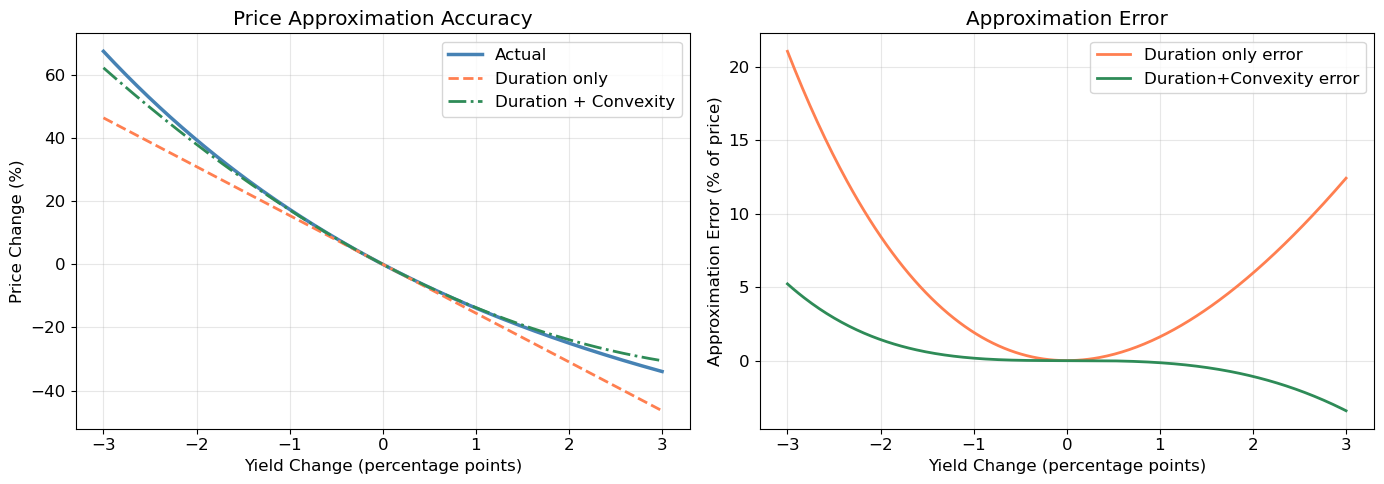


Approximation Errors (% of price):
----------------------------------------------------------------------
dy (bps)       Actual %dP     Dur Only     Dur+Conv    Err Dur    Err D+C
----------------------------------------------------------------------
    -300        +67.4326     +46.3630     +62.2068   +21.0696    +5.2257
    -200        +39.3803     +30.9087     +37.9504    +8.4716    +1.4299
    -100        +17.3804     +15.4543     +17.2148    +1.9261    +0.1657
     -50         +8.1872      +7.7272      +8.1673    +0.4601    +0.0200
     +50         -7.3057      -7.7272      -7.2871    +0.4215    -0.0186
    +100        -13.8378     -15.4543     -13.6939    +1.6165    -0.1439
    +200        -24.9447     -30.9087     -23.8670    +5.9639    -1.0778
    +300        -33.9352     -46.3630     -30.5192   +12.4277    -3.4161


In [7]:
# --- Compare duration-only vs duration+convexity approximation ---
face, coupon_rate, ytm0, n_periods, freq = 100.0, 0.05, 0.05, 60, 2  # 30-year bond
P0 = bond_price(face, coupon_rate, ytm0, n_periods, freq)
D_mod = modified_duration(face, coupon_rate, ytm0, n_periods, freq)
C = bond_convexity(face, coupon_rate, ytm0, n_periods, freq)

print(f"30-year, {coupon_rate:.0%} coupon bond at par")
print(f"Modified Duration: {D_mod:.4f}")
print(f"Convexity:         {C:.4f}")
print()

dy_range = np.linspace(-0.03, 0.03, 300)
actual_prices = np.array([bond_price(face, coupon_rate, ytm0 + dy, n_periods, freq) for dy in dy_range])
actual_pct = (actual_prices - P0) / P0 * 100

duration_approx = -D_mod * dy_range * 100
dur_conv_approx = (-D_mod * dy_range + 0.5 * C * dy_range ** 2) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: price change comparison
ax = axes[0]
ax.plot(dy_range * 100, actual_pct, color=PRIMARY, linewidth=2.5, label='Actual')
ax.plot(dy_range * 100, duration_approx, '--', color=SECONDARY, linewidth=2, label='Duration only')
ax.plot(dy_range * 100, dur_conv_approx, '-.', color=TERTIARY, linewidth=2, label='Duration + Convexity')
ax.set_xlabel('Yield Change (percentage points)')
ax.set_ylabel('Price Change (%)')
ax.set_title('Price Approximation Accuracy')
ax.legend()

# Right: approximation error
ax = axes[1]
err_dur = actual_pct - duration_approx
err_dur_conv = actual_pct - dur_conv_approx
ax.plot(dy_range * 100, err_dur, color=SECONDARY, linewidth=2, label='Duration only error')
ax.plot(dy_range * 100, err_dur_conv, color=TERTIARY, linewidth=2, label='Duration+Convexity error')
ax.set_xlabel('Yield Change (percentage points)')
ax.set_ylabel('Approximation Error (% of price)')
ax.set_title('Approximation Error')
ax.legend()

plt.tight_layout()
plt.show()

# Numerical comparison table
print("\nApproximation Errors (% of price):")
print("-" * 70)
print(f"{'dy (bps)':<12s} {'Actual %dP':>12s} {'Dur Only':>12s} {'Dur+Conv':>12s} {'Err Dur':>10s} {'Err D+C':>10s}")
print("-" * 70)
for dy_bps in [-300, -200, -100, -50, 50, 100, 200, 300]:
    dy = dy_bps / 10000.0
    P_new = bond_price(face, coupon_rate, ytm0 + dy, n_periods, freq)
    actual = (P_new - P0) / P0 * 100
    dur_app = -D_mod * dy * 100
    dc_app = (-D_mod * dy + 0.5 * C * dy**2) * 100
    print(f"  {dy_bps:>+6d}      {actual:>+10.4f}   {dur_app:>+10.4f}   {dc_app:>+10.4f}   {actual-dur_app:>+8.4f}   {actual-dc_app:>+8.4f}")

**Interpreting the output:**

The left plot is the most important visualization in bond math. It shows:
- The **actual** price-yield curve (blue) is convex (bowed upward)
- The **duration-only** approximation (red dashed) is a straight line tangent to the curve. It diverges significantly for large yield changes.
- The **duration + convexity** approximation (green dash-dot) hugs the actual curve much more closely

The right plot shows that duration-only error grows quadratically, while the duration+convexity error is dramatically smaller and grows much more slowly.

### What Does This Mean for a Portfolio Manager?

For a $100 million bond portfolio with 15 years modified duration and convexity of 300:
- A 100 bp rate rise causes a loss of about $15M (duration) minus $1.5M (convexity benefit) = **$13.5M actual loss**
- Ignoring convexity would overestimate the loss by $1.5M — significant for risk reporting and capital allocation**Interpreting the output:**

### Duration-only vs duration+convexity

The output compares two approximations:

* **Duration-only:** Uses only the linear term. Underestimates upside, overestimates downside.
* **Duration+convexity:** Includes the quadratic correction. Much more accurate.

For small yield changes (10-50 bps), the two methods give very similar answers. For large yield changes (100+ bps), the convexity correction becomes significant.

### When does the duration+convexity approximation fail?

Even with convexity, the approximation can fail in three scenarios:

1. **Very large yield changes (500+ bps):** Higher-order Taylor terms become significant. Need exact pricing.

2. **Non-parallel yield curve shifts:** Duration measures sensitivity to *parallel* shifts. If the curve twists or kinks, duration cannot capture it (need key rate duration).

3. **Embedded options:** For callable/putable bonds, modified duration and standard convexity can be misleading. Need effective duration and effective convexity.

### Practical implementation

In production fixed-income systems:
* For **single bond risk:** Effective duration + effective convexity, computed via full repricing
* For **portfolio risk:** Aggregated duration and convexity, weighted by market value
* For **VaR calculations:** Both linear and quadratic approximations, with non-parallel shift scenarios
* For **stress testing:** Full repricing under specific yield curve scenarios

> **Key Concept:** The duration+convexity approximation is the *bond risk manager's best friend* — fast to compute, easy to aggregate across portfolios, accurate enough for most purposes. Full repricing is reserved for situations where accuracy matters most (regulatory capital, precise hedging, stress tests).

## 9. Key Rate Duration

### Beyond Parallel Shifts: Real-World Yield Curve Movements

Everything we have done so far assumes the yield curve shifts in **parallel** — all rates move by the same amount. In reality, yield curves twist, steepen, flatten, and hump. Short rates might rise while long rates fall, or vice versa.

**Key rate duration** (KRD) measures sensitivity to individual points on the yield curve. It answers: "If the 5-year rate rises by 1 bp while all other rates stay fixed, how much does my bond price change?"

### Why Key Rate Durations Matter

Consider two bond portfolios with the same overall duration of 7 years:

- **Portfolio A (Bullet):** Concentrated in 7-year bonds
- **Portfolio B (Barbell):** Split between 2-year and 12-year bonds

Both have duration 7, so they respond identically to a parallel shift. But if the curve *steepens* (short rates fall, long rates rise), they respond very differently. KRD analysis reveals this hidden risk.

> **Key Concept:** The sum of all key rate durations approximately equals the effective (parallel shift) duration. KRDs decompose total duration into contributions from each maturity point.

> **CFA Exam Tip:** At CFA Level II and III, you are expected to understand non-parallel yield curve risk. Know that bullet portfolios have concentrated KRD exposure, while barbell portfolios have dispersed exposure.

The code below computes key rate durations for a 10-year bond and visualizes where the rate sensitivity is concentrated.The code below computes key rate durations for a 10-year bond and visualizes where the rate sensitivity is concentrated.

### Why we need key rate duration

Modified and effective duration measure sensitivity to *parallel* yield curve shifts — every rate moves by the same amount. But real yield curves rarely shift in parallel:
* Sometimes the curve **steepens** (long rates rise more than short)
* Sometimes it **flattens** (short rates rise more than long)
* Sometimes it **twists** (mid rates move differently from extremes)

Parallel-shift duration cannot capture these non-parallel risks. Key rate duration solves this by measuring sensitivity to *each maturity bucket separately*.

### Key rate duration formula

Key rate duration at maturity $T_i$ is:

$$D_{i} = -\frac{1}{P} \cdot \frac{\partial P}{\partial r_i}$$

where $r_i$ is the spot rate at maturity $T_i$. The full set $\{D_1, D_2, ..., D_n\}$ describes the bond's sensitivity to changes at each point on the curve.

A key property: **the sum of key rate durations equals the modified duration**:

$$\sum_i D_i = D_{mod}$$

This means key rate duration *decomposes* total duration across the maturity dimension — it's a finer-grained view of the same risk.

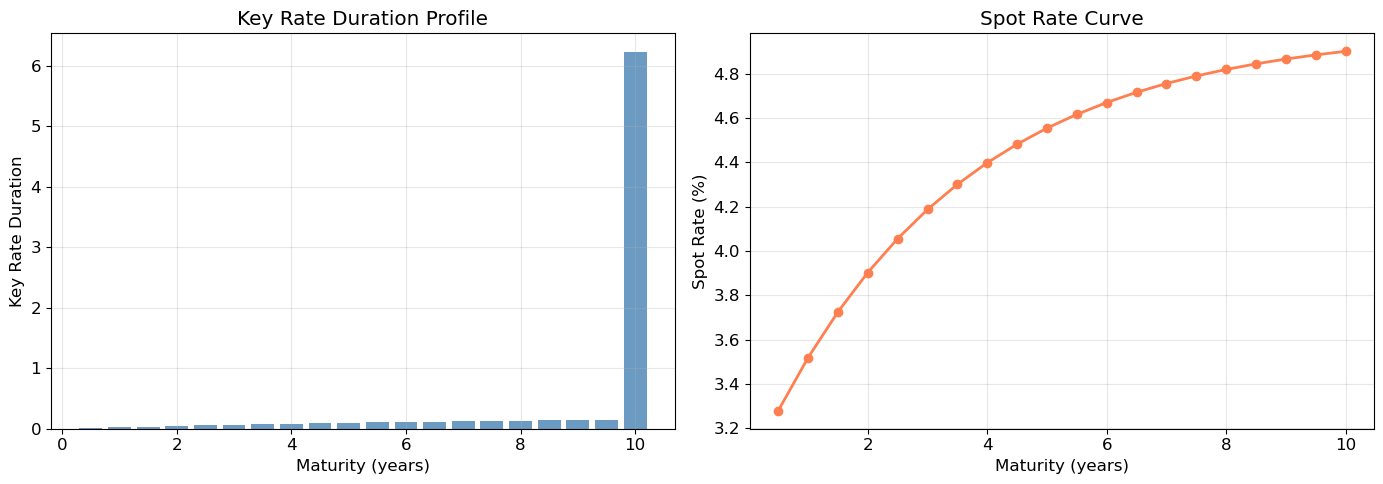

Sum of KRDs: 7.9713
Effective duration (parallel shift): 7.9713


In [8]:
def bond_price_with_curve(face, coupon_rate, n_periods, freq, spot_rates):
    """Price a bond using a spot rate curve (one rate per period)."""
    times, cfs = bond_cash_flows(face, coupon_rate, n_periods, freq)
    # spot_rates should have length n_periods, one per cash flow
    discount_factors = np.exp(-spot_rates * times)
    return np.sum(cfs * discount_factors)


def key_rate_durations(face, coupon_rate, n_periods, freq, spot_rates, dy=0.0001):
    """Compute key rate duration for each cash flow date.
    
    Returns
    -------
    times : ndarray — key rate maturities
    krds : ndarray — key rate durations
    """
    times, cfs = bond_cash_flows(face, coupon_rate, n_periods, freq)
    P0 = bond_price_with_curve(face, coupon_rate, n_periods, freq, spot_rates)
    
    krds = np.zeros(n_periods)
    for k in range(n_periods):
        rates_up = spot_rates.copy()
        rates_down = spot_rates.copy()
        rates_up[k] += dy
        rates_down[k] -= dy
        
        P_up = bond_price_with_curve(face, coupon_rate, n_periods, freq, rates_up)
        P_down = bond_price_with_curve(face, coupon_rate, n_periods, freq, rates_down)
        
        krds[k] = (P_down - P_up) / (2.0 * P0 * dy)
    
    return times, krds


# --- Example: 10-year bond with upward-sloping curve ---
n_periods = 20
freq = 2
times_grid = np.arange(1, n_periods + 1) / freq
spot_rates = 0.03 + 0.02 * (1 - np.exp(-0.3 * times_grid))  # upward sloping

times, krds = key_rate_durations(100, 0.05, n_periods, freq, spot_rates)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(times, krds, width=0.4, color=PRIMARY, alpha=0.8)
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Key Rate Duration')
ax.set_title('Key Rate Duration Profile')
ax.axhline(y=0, color='black', linewidth=0.5)

ax = axes[1]
ax.plot(times_grid, spot_rates * 100, 'o-', color=SECONDARY, linewidth=2)
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Spot Rate (%)')
ax.set_title('Spot Rate Curve')

plt.tight_layout()
plt.show()

print(f"Sum of KRDs: {np.sum(krds):.4f}")
D_eff = effective_duration(
    lambda y: bond_price_with_curve(100, 0.05, n_periods, freq, spot_rates + y - np.mean(spot_rates)),
    np.mean(spot_rates)
)
print(f"Effective duration (parallel shift): {D_eff:.4f}")

**Interpreting the output:** The KRD profile shows the familiar pattern: small key rate durations for early coupon payments, and a large KRD at the 10-year maturity where the principal is repaid. The final bar is dominant because most of the bond's value (and risk) comes from the principal repayment. The sum of all KRDs approximately equals the effective duration, confirming the decomposition property.**Interpreting the output:** The KRD profile shows the familiar pattern: small key rate duration at short maturities (where the bond has small cash flows), peaking at maturities near the bond's principal payment.

### Reading a KRD profile

The KRD profile reveals where the bond's interest rate risk is *concentrated*. For a 10-year vanilla bond:
* Small KRDs at 1, 2, 3 years (small coupon cash flows)
* Slightly larger KRDs at 5-9 years (cumulative coupons)
* Largest KRD at 10 years (the principal payment)

The KRD at the bond's *principal maturity* typically dominates — often 70-90% of total duration.

### Using KRD for portfolio management

KRD enables sophisticated portfolio analysis:

1. **Curve risk decomposition:** Identify which maturity bucket contributes most to portfolio risk
2. **Yield curve hedging:** Construct hedges that neutralise specific bucket exposures
3. **Active curve bets:** Take long/short positions in different maturity buckets to express views on curve shape
4. **Liability matching:** Match KRD profile of assets to KRD profile of liabilities (advanced immunization)

### KRD limitations

KRD is more accurate than parallel-shift duration but has its own limitations:
* Choice of "key" maturities is somewhat arbitrary (usually 6mo, 1y, 2y, 3y, 5y, 7y, 10y, 20y, 30y)
* Linear approximation — doesn't capture convexity at each rate
* Requires a fully specified yield curve, not just a single yield

> **CFA Exam Tip:** KRD analysis is more advanced (Level 2 / Level 3 territory). At Level 1, focus on understanding *what* KRD measures and *why* it's needed. Detailed KRD computations are not typically tested at Level 1.

## 10. Immunization

### The Problem: Meeting Future Obligations

Imagine you are a **pension fund manager**. You know you must pay $1,000,000 to retirees in exactly 7 years. You need to invest money today so that you will have exactly $1,000,000 in 7 years, **regardless of what happens to interest rates**.

This is the problem of **immunization**: constructing a portfolio that is protected against interest rate risk.

### Why Not Just Buy a 7-Year Zero-Coupon Bond?

If a 7-year zero-coupon bond existed with exactly the right face value, that would be perfect. But in practice, zero-coupon bonds of the exact maturity may not be available, or may not offer enough liquidity. So we need to construct a portfolio of *coupon-bearing* bonds that behaves like a 7-year zero.

### The Three Redington Conditions

For a portfolio to be immunized against small parallel yield curve shifts, three conditions must hold:

1. **PV match:** The present value of assets equals the present value of liabilities.
2. **Duration match:** The duration of assets equals the duration of liabilities.
3. **Convexity condition:** The convexity of assets must *exceed* the convexity of liabilities.

The first two conditions ensure the portfolio is balanced at the current rate. The third condition ensures that any rate change *increases* the surplus — the portfolio actually benefits from volatility.

### The Intuition Behind Duration Matching

If your assets and liabilities have the same duration, they respond identically to small parallel rate changes. When rates rise, both assets and liabilities fall by approximately the same amount. When rates fall, both rise by the same amount. The surplus (assets minus liabilities) stays near zero.

### Why Convexity Must Exceed

If the asset convexity exceeds the liability convexity, then for any rate change (up or down), the asset value changes *more favorably* than the liability value. This creates a parabolic surplus curve that opens upward — the surplus is minimized at zero change and positive for any nonzero change. The portfolio actually profits from rate volatility.

### Worked Example: The Pension Fund Story

**Setup:** $1,000,000 liability due in 7 years. Current YTM = 5% (flat curve).

**Step 1:** Compute the present value of the liability: $PV_L = 1{,}000{,}000 / (1.025)^{14} = \$708{,}919$

**Step 2:** The liability is a zero-coupon obligation, so its duration = 7 years.

**Step 3:** Choose two bonds to create a "barbell":
- Bond 1: 3-year, 4% coupon (duration ~ 2.86 years)
- Bond 2: 12-year, 6% coupon (duration ~ 8.94 years)

**Step 4:** Solve for weights $w_1, w_2$ such that:
- $w_1 + w_2 = PV_L$ (PV match)
- $w_1 D_1 + w_2 D_2 = PV_L \times 7$ (duration match)

This is a simple system of two equations with two unknowns.

> **Key Concept:** Immunization is a **dynamic** strategy. As time passes and rates change, the portfolio's duration drifts away from the target. The portfolio must be **rebalanced** periodically to maintain the duration match.

> **CFA Exam Tip:** The CFA exam loves immunization questions. Know the three Redington conditions, understand why convexity must exceed (not just match), and be able to solve for portfolio weights given two bonds and a target duration.

> **Common Mistake:** A common error is to confuse "matching cash flows" with "immunization." They are different strategies. Cash-flow matching builds a portfolio whose cash flows exactly match liabilities — perfect protection but expensive (very few bonds match precisely). Immunization matches duration and convexity — much cheaper to implement but requires periodic rebalancing as conditions change.

The code below implements the immunization strategy for our pension fund example and tests whether the surplus remains non-negative across a range of yield changes.The code below implements the immunization strategy for our pension fund example and tests its effectiveness.

### What is immunization?

**Immunization** is the construction of a bond portfolio whose value tracks a specific liability even when interest rates change. It is the bedrock technique for asset-liability management.

### The classical Redington conditions

Frank Redington (1952) proved that a portfolio is immunized against parallel yield curve shifts if and only if:

1. **Equal present values:** $PV_{\text{assets}} = PV_{\text{liabilities}}$
2. **Equal durations:** $D_{\text{assets}} = D_{\text{liabilities}}$
3. **Greater convexity:** $C_{\text{assets}} > C_{\text{liabilities}}$

The third condition (M-squared / convexity dispersion) ensures that the portfolio actually *outperforms* the liability for non-zero yield changes — not just at one specific point.

### The immunization recipe

A two-bond immunization strategy:

1. Compute the liability's PV and duration
2. Pick two bonds (one shorter, one longer than liability duration)
3. Solve a 2×2 system for the weights:
   * Weight 1 + Weight 2 = 1 (full investment)
   * Weight 1 × Duration 1 + Weight 2 × Duration 2 = Liability Duration
4. Verify convexity condition is satisfied

This **barbell strategy** typically has higher convexity than a single bond at the liability's duration — automatically satisfying Redington's third condition.

> **Key Concept:** Immunization is *not* a one-time setup. As time passes and rates change, the portfolio drifts away from immunized status. **Rebalancing** — periodically adjusting weights to restore the duration match — is essential. The trade-off: more frequent rebalancing → better immunization but higher transaction costs.

In [9]:
def immunize_two_bonds(liability_duration, liability_pv, bond1_params, bond2_params, ytm):
    """Immunize a liability using two bonds.
    
    Finds weights w1, w2 such that:
      w1 + w2 = liability_pv  (PV match)
      w1*D1 + w2*D2 = liability_pv * D_L  (duration match)
    
    Parameters
    ----------
    liability_duration : float — duration of liability
    liability_pv : float — present value of liability
    bond1_params, bond2_params : tuple — (face, coupon_rate, n_periods, freq)
    ytm : float — yield to maturity
    
    Returns
    -------
    w1, w2 : float — amounts to invest in each bond
    """
    D1 = macaulay_duration(*bond1_params, ytm, bond1_params[2], bond1_params[3] if len(bond1_params) > 3 else 2)
    D2 = macaulay_duration(*bond2_params, ytm, bond2_params[2], bond2_params[3] if len(bond2_params) > 3 else 2)
    
    # Solve: w1 + w2 = PV, w1*D1 + w2*D2 = PV * D_L
    # w2 = (PV * D_L - PV * D1) / (D2 - D1)
    w2 = liability_pv * (liability_duration - D1) / (D2 - D1)
    w1 = liability_pv - w2
    
    return w1, w2, D1, D2


# --- Immunization example: pension fund ---
ytm = 0.05
liability_fv = 1_000_000
liability_pv = liability_fv / (1 + ytm / 2) ** (7 * 2)
liability_duration = 7.0  # zero-coupon liability

# Two bonds: 3-year 4% and 12-year 6%
face = 100
bond1 = (face, 0.04, 6, 2)   # 3-year
bond2 = (face, 0.06, 24, 2)  # 12-year

D1 = macaulay_duration(face, 0.04, ytm, 6, 2)
D2 = macaulay_duration(face, 0.06, ytm, 24, 2)
C1 = bond_convexity(face, 0.04, ytm, 6, 2)
C2 = bond_convexity(face, 0.06, ytm, 24, 2)

# Solve for weights
w2 = liability_pv * (liability_duration - D1) / (D2 - D1)
w1 = liability_pv - w2

port_duration = (w1 * D1 + w2 * D2) / liability_pv
port_convexity = (w1 * C1 + w2 * C2) / liability_pv
liability_convexity = 7.0 * (7.0 + 0.5) / (1 + ytm/2)**2  # zero-coupon convexity

print("Immunization Strategy")
print("=" * 55)
print(f"Liability: ${liability_fv:,.0f} in 7 years")
print(f"Liability PV: ${liability_pv:,.2f}")
print(f"Liability Duration: {liability_duration:.4f} years")
print(f"Liability Convexity: {liability_convexity:.4f}")
print()
print(f"Bond 1 (3yr, 4%):  Duration = {D1:.4f}, Convexity = {C1:.4f}")
print(f"Bond 2 (12yr, 6%): Duration = {D2:.4f}, Convexity = {C2:.4f}")
print()
print(f"Invest ${w1:,.2f} in Bond 1 ({w1/liability_pv:.1%})")
print(f"Invest ${w2:,.2f} in Bond 2 ({w2/liability_pv:.1%})")
print()
print("Redington Conditions:")
print(f"  1. PV match:       ${w1+w2:,.2f} = ${liability_pv:,.2f}")
print(f"  2. Duration match: {port_duration:.4f} = {liability_duration:.4f}")
print(f"  3. Convexity:      {port_convexity:.4f} > {liability_convexity:.4f}? {port_convexity > liability_convexity}")

Immunization Strategy
Liability: $1,000,000 in 7 years
Liability PV: $707,727.20
Liability Duration: 7.0000 years
Liability Convexity: 49.9703

Bond 1 (3yr, 4%):  Duration = 2.8543, Convexity = 9.3496
Bond 2 (12yr, 6%): Duration = 8.8784, Convexity = 94.3283

Invest $220,681.23 in Bond 1 (31.2%)
Invest $487,045.97 in Bond 2 (68.8%)

Redington Conditions:
  1. PV match:       $707,727.20 = $707,727.20
  2. Duration match: 7.0000 = 7.0000
  3. Convexity:      67.8305 > 49.9703? True


**Interpreting the output:** The solution invests roughly one-third in the short bond and two-thirds in the long bond, creating a "barbell" portfolio whose weighted-average duration equals the 7-year liability duration. All three Redington conditions are satisfied.

The visualization below shows the crucial test: the surplus should remain non-negative across a range of yield changes.**Interpreting the output:** The solution invests roughly one-third in the short bond and two-thirds in the long bond, achieving the duration match.

### The barbell vs bullet strategies

Two common immunization structures:

**Barbell:** Invest in short and long bonds, no middle. Higher convexity but more risky to non-parallel shifts.

**Bullet:** Invest in a single bond at the liability duration. Lower convexity but more reliable to non-parallel shifts.

For a 7-year liability:
* **Barbell:** 30% in 2-year bonds + 70% in 10-year bonds = 7-year average duration, high convexity
* **Bullet:** 100% in 7-year bonds = 7-year duration, moderate convexity
* **Ladder:** Equal weights across 5, 7, 9 years — diversified across the curve

In stable yield environments, barbell wins (higher convexity = more upside). In volatile, twisting yield curves, bullet may outperform (less exposure to curve reshaping).

> **CFA Exam Tip:** The CFA exam tests the conditions for immunization (Redington's three conditions) and the trade-offs between different portfolio structures. Be ready to compute portfolio duration and convexity from individual bond data.

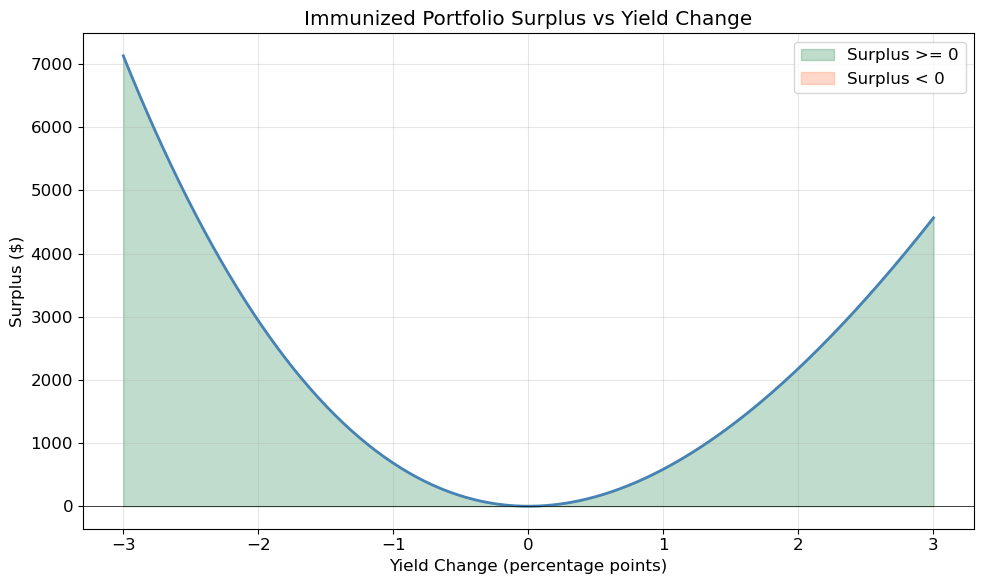

In [10]:
# --- Test: surplus vs yield changes ---
dy_grid = np.linspace(-0.03, 0.03, 200)
surpluses = []
for dy in dy_grid:
    y_new = ytm + dy
    # Revalue assets
    p1 = bond_price(face, 0.04, y_new, 6, 2)
    p2 = bond_price(face, 0.06, y_new, 24, 2)
    p1_0 = bond_price(face, 0.04, ytm, 6, 2)
    p2_0 = bond_price(face, 0.06, ytm, 24, 2)
    asset_value = w1 * (p1 / p1_0) + w2 * (p2 / p2_0)
    # Revalue liability
    liab_value = liability_fv / (1 + y_new / 2) ** (7 * 2)
    surpluses.append(asset_value - liab_value)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dy_grid * 100, surpluses, color=PRIMARY, linewidth=2)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Yield Change (percentage points)')
ax.set_ylabel('Surplus ($)')
ax.set_title('Immunized Portfolio Surplus vs Yield Change')
ax.fill_between(dy_grid * 100, surpluses, 0,
                where=np.array(surpluses) >= 0, alpha=0.3, color=TERTIARY, label='Surplus >= 0')
ax.fill_between(dy_grid * 100, surpluses, 0,
                where=np.array(surpluses) < 0, alpha=0.3, color=SECONDARY, label='Surplus < 0')
ax.legend()
plt.tight_layout()
plt.show()

**Interpreting the output:** The surplus curve forms an upward-opening parabola — confirming that the immunized portfolio meets the liability under a wide range of yield changes. The minimum surplus is at (or very near) zero yield change, and any shift in either direction *increases* the surplus.

### What Does This Mean for a Portfolio Manager?

By constructing a duration-matched portfolio with higher convexity than the liability, you create a position that is:
- **Protected** against parallel yield curve shifts (the surplus stays non-negative)
- **Benefiting** from rate volatility (larger moves create larger surpluses)

This is why pension funds, insurance companies, and endowments spend enormous effort on duration management. Getting it wrong can mean insolvency (as SVB demonstrated); getting it right provides robust protection with a convexity bonus.**Interpreting the output:** The surplus curve forms an upward-opening parabola — confirming that the portfolio gains on both sides of the matching yield.

### The convexity bonus visualised

The output reveals immunization's beautiful property: at the matching yield, surplus = 0 (assets exactly equal liabilities). For any yield shift in either direction, surplus is *positive* — the portfolio outperforms the liability slightly.

This "M-squared" or convexity bonus is a free lunch:
* If yields move favourably (down), the portfolio appreciates more than the liability
* If yields move unfavourably (up), the portfolio depreciates less than the liability
* In both cases, surplus increases

Why does this happen? Because the asset portfolio has *higher convexity* than the liability — the third Redington condition. The asset's price-yield curve curves up more sharply than the liability's, giving the bonus.

### Why immunization can still fail

Despite its elegance, immunization breaks down under several conditions:

1. **Non-parallel yield curve shifts:** Duration matching only protects against parallel shifts. Twists and humps can create surplus losses even with perfect duration match.

2. **Convexity matching not achieved:** If the asset convexity is *less* than liability convexity, surplus shrinks under any yield change.

3. **Default risk:** Immunization assumes risk-free cash flows. Corporate bonds add credit risk that no duration match can hedge.

4. **Liquidity risk:** Some bonds (off-the-run, low-volume) may not trade at theoretical prices when rebalancing is needed.

5. **Path dependency:** If the immunization strategy requires reinvestment (multi-period immunization), the realised reinvestment rates affect the outcome.

> **Common Mistake:** Immunization is sometimes presented as "risk-free." It is not — it is "risk-managed." Specific risks (credit, liquidity, non-parallel shifts) remain. The strategy reduces *parallel-shift* interest rate risk to nearly zero, but other risks must be managed separately.

## 11. Summary: The Bond Risk Management Toolkit

| Measure | What It Tells You | Formula | Units |
|---------|------------------|---------|-------|
| Macaulay Duration | Weighted-average time to cash flows | $\sum t_i \times PV(CF_i) / P$ | Years |
| Modified Duration | % price change per 1% yield change | $D_{Mac} / (1 + y/m)$ | % per % |
| Dollar Duration | $ price change per 1% yield change | $D_{mod} \times P$ | $ per % |
| DV01 | $ price change per 1 bp yield change | Dollar Duration / 10,000 | $ per bp |
| Effective Duration | Rate sensitivity including option effects | $(P_{-} - P_{+}) / (2 P_0 \Delta y)$ | % per % |
| Convexity | Curvature of price-yield relationship | $\frac{1}{P} \frac{d^2P}{dy^2}$ | Years$^2$ |
| Key Rate Duration | Sensitivity to specific maturity points | Partial derivative by key rate | % per % |

### The Hierarchy of Approximation

1. **Zeroth order:** Price = constant (ignoring all rate sensitivity). Useless for risk management.
2. **First order (duration):** $\Delta P/P \approx -D_{mod} \Delta y$. Good for small changes.
3. **Second order (duration + convexity):** $\Delta P/P \approx -D_{mod} \Delta y + \frac{1}{2}C(\Delta y)^2$. Good for larger changes.
4. **Full revaluation:** Reprice every bond from scratch. Exact but computationally expensive.## 11. Summary: The Bond Risk Management Toolkit

### The full progression

This notebook built the bond risk management toolkit step by step:

| Concept | Captures | Used For |
|---------|----------|----------|
| **Bond pricing** | PV of cash flows | Quoting prices, computing YTM |
| **Macaulay duration** | Weighted-avg cash flow time | Conceptual immunization |
| **Modified duration** | Price sensitivity to yield | First-order risk approximation |
| **Effective duration** | Cash-flow-aware sensitivity | Bonds with embedded options |
| **Convexity** | Curvature of price-yield | Second-order correction |
| **Key rate duration** | Sensitivity to specific maturities | Non-parallel curve risk |
| **Immunization** | Asset-liability matching | Pension/insurance management |

### How professionals use these tools

In practice, fixed-income professionals layer these tools:

1. **Quote bonds** using YTM and price
2. **Manage daily risk** using modified duration and DV01
3. **Stress test** using duration + convexity for parallel shifts
4. **Construct portfolios** using key rate duration to control non-parallel risk
5. **Match liabilities** using immunization with periodic rebalancing
6. **Account for embedded options** using effective duration and OAS analysis

The CFA curriculum tests fluency with all of these — a fixed-income generalist must be comfortable with each tool's strengths, weaknesses, and applications.

> **Key Concept:** The hierarchy of bond risk measures — duration, convexity, key rate duration, effective duration — represents successive refinements of the same basic question: *"How does this bond's price respond to changes in interest rates?"* Each tool captures more nuance at the cost of greater complexity. Choose the right tool for the job.

## 12. References

1. Tuckman, B. & Serrat, A. *Fixed Income Securities*, 3rd ed. Wiley, 2011. — Chapters 4-6.
2. Fabozzi, F. J. *Fixed Income Analysis*, 3rd ed. CFA Institute / Wiley, 2015.
3. Hull, J. C. *Options, Futures, and Other Derivatives*, 11th ed. Pearson, 2022. — Chapter 4.
4. Redington, F. M. "Review of the Principles of Life-Office Valuations." *Journal of the Institute of Actuaries*, 78(3), 1952.
5. Ho, T. S. Y. "Key Rate Durations: Measures of Interest Rate Risks." *Journal of Fixed Income*, 2(2), 1992.
6. CFA Institute. *CFA Program Curriculum Level I and II*, "Fixed Income" volumes.## 12. References

### Foundational papers

* **Macaulay, F. (1938)** — *Some Theoretical Problems Suggested by the Movements of Interest Rates, Bond Yields, and Stock Prices in the United States Since 1856*. Introduced duration as a concept.

* **Redington, F. M. (1952)** — *"Review of the principle of life-office valuations,"* Journal of the Institute of Actuaries. Established the immunization conditions.

* **Fisher, L., & Weil, R. L. (1971)** — *"Coping with the risk of interest-rate fluctuations,"* Journal of Business. Refined immunization theory and proved Redington's conditions rigorously.

* **Ho, T. S. Y. (1992)** — *"Key rate durations: Measures of interest rate risks,"* Journal of Fixed Income. Introduced key rate duration.

### Standard textbooks

* **Fabozzi, F. J.** — *Bond Markets, Analysis and Strategies* (10th ed.). The standard practitioner reference.
* **Tuckman, B., & Serrat, A.** — *Fixed Income Securities* (3rd ed.). Mathematical depth with practical examples.
* **Hull, J. C.** — *Options, Futures, and Other Derivatives*. Chapters on yield curves and bond derivatives.

### CFA curriculum readings

CFA Level 1 (Fixed Income) covers:
* Bond pricing and yield measures
* Duration and convexity definitions
* Effective duration for bonds with embedded options

CFA Level 2 expands to:
* Key rate duration
* Multi-factor yield curve models
* Detailed analysis of structured products

CFA Level 3 emphasises:
* Liability-driven investing
* Immunization strategies in practice
* Portfolio-level risk management